In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
df = yf.Ticker("SPY").history(period="max")

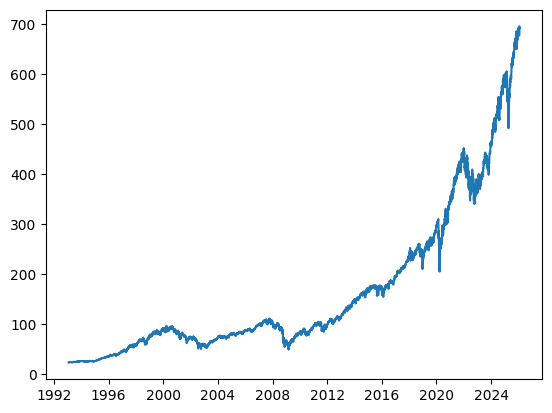

In [3]:
plt.plot(df['Close'])

In [4]:
df['MA'] = df['Close'].rolling(50).mean()
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,MA
Date,,,,,,,,,
1993-01-29 00:00:00-05:00,24.258643,24.258643,24.137953,24.241402,1003200,0.0,0.0,0.0,NaN
1993-02-01 00:00:00-05:00,24.258640,24.413813,24.258640,24.413813,480500,0.0,0.0,0.0,NaN
1993-02-02 00:00:00-05:00,24.396576,24.482783,24.344852,24.465542,201300,0.0,0.0,0.0,NaN
1993-02-03 00:00:00-05:00,24.500019,24.741399,24.482778,24.724157,529400,0.0,0.0,0.0,NaN
1993-02-04 00:00:00-05:00,24.810376,24.879342,24.534514,24.827618,531500,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...
2026-01-26 00:00:00-05:00,690.489990,694.130005,689.919983,692.729980,60473800,0.0,0.0,0.0,681.090768
2026-01-27 00:00:00-05:00,694.179993,696.530029,693.570007,695.489990,55506100,0.0,0.0,0.0,681.373235
2026-01-28 00:00:00-05:00,697.049988,697.840027,693.940002,695.419983,61172200,0.0,0.0,0.0,681.880435


Text(0.5, 1.0, 'SPY Close vs. Moving Average')

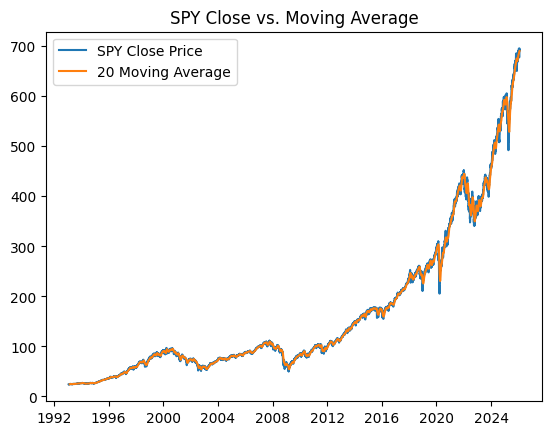

In [5]:
TICKER = 'SPY'

WINDOW = (20)

df = yf.Ticker(TICKER).history(period="max")
df['MA'] = df['Close'].rolling(WINDOW).mean()

plt.plot(df['Close']) 
plt.plot(df['MA'])
plt.legend([f'{TICKER} Close Price', f'{WINDOW} Moving Average'])
plt.title(f'{TICKER} Close vs. Moving Average')

In [6]:
df.columns = df.columns.get_level_values(0)


def add_ma_strategy(df):
    df['Strategy'] = np.where(df['Close'] > df['MA'], 1, -1)

    return df


df = add_ma_strategy(df)
df['asset_cumulative'] = np.cumprod(1 + df['Close'].pct_change()) - 1  # This shows what the multiplier would have been if you bought and held for 50 years.
df['strategy_cumulative'] =  np.cumprod(1 + df['Close'].pct_change() * df['Strategy'].shift()) - 1 

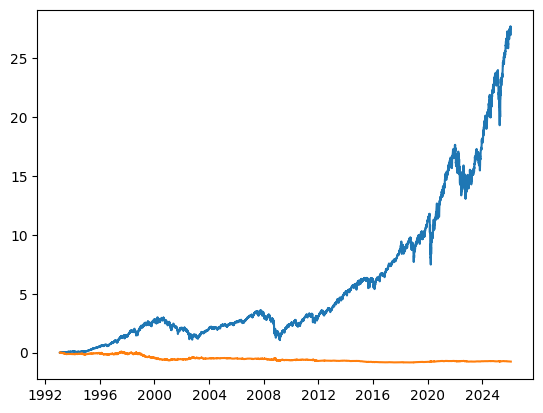

In [7]:
plt.plot(df['asset_cumulative'])
plt.plot(df['strategy_cumulative'])

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains,MA,Strategy,asset_cumulative,strategy_cumulative
Date,,,,,,,,,,,,
2025-02-28 00:00:00-05:00,578.763503,587.817158,575.679721,587.283447,88744100,0.0,0.0,0.0,595.288925,NaN,NaN,NaN
2025-03-03 00:00:00-05:00,589.260195,590.406764,573.169186,576.994263,74249200,0.0,0.0,0.0,594.396899,-1.0,-0.017520,0.017520
2025-03-04 00:00:00-05:00,572.981447,578.595513,565.608012,570.164490,109648200,0.0,0.0,0.0,593.363535,-1.0,-0.029149,0.029564
2025-03-05 00:00:00-05:00,569.996421,578.091363,566.428337,576.292480,71230500,0.0,0.0,0.0,592.438397,-1.0,-0.018715,0.018499
2025-03-06 00:00:00-05:00,568.800430,573.435996,563.502657,566.062622,80094900,0.0,0.0,0.0,590.881183,-1.0,-0.036134,0.036578
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-26 00:00:00-05:00,690.489990,694.130005,689.919983,692.729980,60473800,0.0,0.0,0.0,689.002994,1.0,0.179550,-0.083667
2026-01-27 00:00:00-05:00,694.179993,696.530029,693.570007,695.489990,55506100,0.0,0.0,0.0,689.261993,1.0,0.184249,-0.080016
2026-01-28 00:00:00-05:00,697.049988,697.840027,693.940002,695.419983,61172200,0.0,0.0,0.0,689.640494,1.0,0.184130,-0.080109


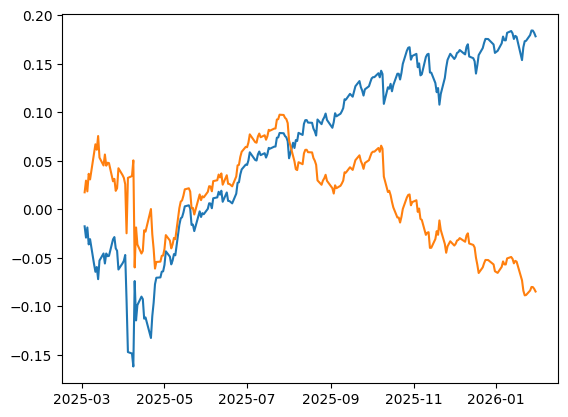

In [8]:
def get_data():
    df = yf.Ticker(TICKER).history(period="1y")
    df.columns = df.columns.get_level_values(0)
    df['MA'] = df['Close'].rolling(WINDOW).mean()

    return df.dropna()


def add_strategy(df):
    df.columns = df.columns.get_level_values(0)
    df['Strategy'] = np.where(df['Close'] > df['MA'], 1, -1)
    df['Strategy'] = df['Strategy'].shift(1)
    return df


def test_strategy(df):
    df['asset_cumulative'] = np.cumprod(1 + df['Close'].pct_change()) - 1
    df['strategy_cumulative'] = np.cumprod(1 + df['Close'].pct_change() * df['Strategy']) - 1
    plt.plot(df['asset_cumulative'])
    plt.plot(df['strategy_cumulative'])
    return df


def main():
    df = get_data()
    df = add_strategy(df)
    df = test_strategy(df)
    return df


main()